In [2]:
import pandas as pd
df=pd.read_csv("olist_no_missing_dataset.csv") #for interpretation of clustering results
cluster_df = pd.read_csv("olist_cleaned_dataset.csv")

In [2]:
cluster_df=cluster_df.drop(columns=['city','state','customer_unique_id','most_bought_category','aov_range','avg_item_price_range','least_bought_category','least_used_payment'])

In [3]:
cluster_df=cluster_df.drop(columns=['avg_order_value','avg_item_price_per_order'])

In [4]:
X = cluster_df.copy()

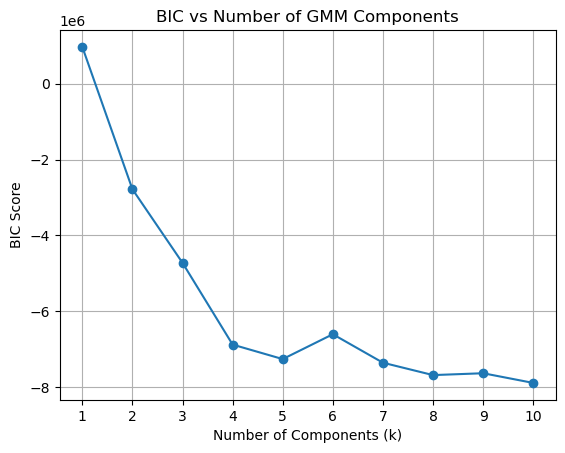

In [5]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

Ks = range(1, 11)
bics = []

for k in Ks:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X)
    bics.append(gmm.bic(X))

plt.plot(Ks, bics, marker='o')
plt.xlabel("Number of Components (k)")
plt.ylabel("BIC Score")
plt.title("BIC vs Number of GMM Components")
plt.xticks(Ks)
plt.grid(True)
plt.show()

In [7]:
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
gmm.fit(X)
cluster_labels = gmm.predict(X)
df['cluster'] = cluster_labels

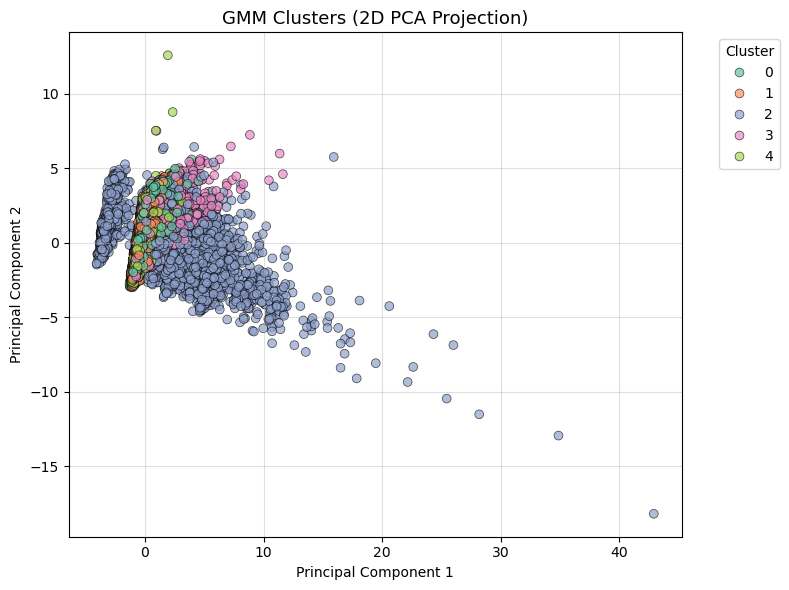

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
# Perform PCA to reduce to 2 components
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(cluster_df)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['cluster'] = cluster_labels
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='cluster',
    data=pca_df,
    palette='Set2',
    s=40, alpha=0.7, edgecolor='k'
)

plt.title('GMM Clusters (2D PCA Projection)', fontsize=13)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import silhouette_score
silhouette_score(X, cluster_labels)

-0.015978777815709673

In [12]:
np.unique(cluster_labels, return_counts=True)

(array([0, 1, 2, 3, 4]), array([16580, 31779,  7779, 11438, 25782]))

In [13]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
davies_bouldin_score(X, cluster_labels)

7.170849520323893

In [14]:
calinski_harabasz_score(X, cluster_labels)

2033.9582550502332

In [4]:
# Select only the columns needed for RFM
rfm = df[['customer_unique_id', 'num_orders', 'total_spent', 'recency_days']].copy()

# Rename columns to RFM format
rfm = rfm.rename(columns={
    'num_orders': 'frequency',
    'total_spent': 'monetary_value',
    'recency_days': 'recency'
})

# Inspect RFM table
print(rfm.head())
print(rfm.shape)

                 customer_unique_id  frequency  monetary_value  recency
0  0000366f3b9a7992bf8c76cfdf3221e2          1          129.90    153.0
1  0000b849f77a49e4a4ce2b2a4ca5be3f          1           18.90    159.0
2  0000f46a3911fa3c0805444483337064          1           69.00    559.0
3  0000f6ccb0745a6a4b88665a16c9f078          1           25.99    349.0
4  0004aac84e0df4da2b147fca70cf8255          1          180.00    323.0
(93358, 4)


In [6]:
# R scores: lower recency is better → reverse quantiles
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])
# F and M scores: higher is better → normal quantiles
rfm['F_score'] = pd.cut(
    rfm['frequency'],
    bins=[0, 1, 2, 3, 5, rfm['frequency'].max()],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
)
rfm['M_score'] = pd.qcut(rfm['monetary_value'], 5, labels=[1,2,3,4,5])
# Combine into a single RFM Score
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) + 
    rfm['F_score'].astype(str) + 
    rfm['M_score'].astype(str)
)
rfm.head()

,customer_unique_id,frequency,monetary_value,recency,R_score,F_score,M_score,RFM_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,153.0,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,159.0,4,1,1,411
2,0000f46a3911fa3c0805444483337064,1,69.00,559.0,1,1,3,113
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,349.0,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,323.0,2,1,5,215


In [7]:
def rfm_segment(x):
    r = int(x['R_score'])
    f = int(x['F_score'])
    m = int(x['M_score'])
    if r >= 4 and f >= 2 and m >= 4:
        return "Best Customer"
    if m >= 4:
        return "Big Spender"
    if r >= 4 and f >= 2:
        return "Loyalist"
    if (r >= 3):
        return "Potential Loyalist"
    if (r == 2 and f>=2) or (r==2 and m>=2):
        return "At Risk"
    if r == 1:
        return "Lost Customer"
    return "Hibernating"    
rfm['segment'] = rfm.apply(rfm_segment, axis=1)

In [8]:
rfm.head()

,customer_unique_id,frequency,monetary_value,recency,R_score,F_score,M_score,RFM_Score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,153.0,4,1,4,414,Big Spender
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,159.0,4,1,1,411,Potential Loyalist
2,0000f46a3911fa3c0805444483337064,1,69.00,559.0,1,1,3,113,Lost Customer
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,349.0,2,1,1,211,Hibernating
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,323.0,2,1,5,215,Big Spender


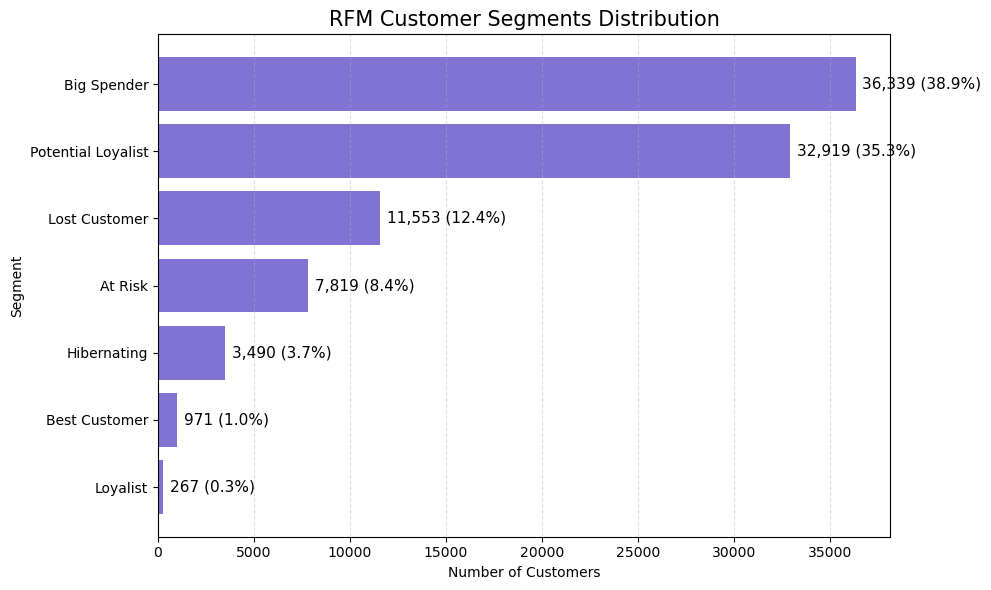

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count customers in each RFM segment
segment_counts = rfm['segment'].value_counts().sort_values(ascending=True)

# Calculate percentages
percentages = (segment_counts / segment_counts.sum() * 100).round(1)

# Prepare labels with counts + percentages
labels = [f"{count:,} ({pct}%)" for count, pct in zip(segment_counts, percentages)]

plt.figure(figsize=(10, 6))
bars = plt.barh(segment_counts.index, segment_counts, color="slateblue", alpha=0.85)

# Add text labels next to bars
for bar, label in zip(bars, labels):
    plt.text(
        bar.get_width() + max(segment_counts)*0.01,
        bar.get_y() + bar.get_height()/2,
        label,
        va='center',
        fontsize=11
    )

plt.title("RFM Customer Segments Distribution", fontsize=15)
plt.xlabel("Number of Customers")
plt.ylabel("Segment")
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
